In [304]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
import scipy
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.preprocessing import PowerTransformer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Lasso, Ridge
from catboost import CatBoostRegressor

In [305]:
data_train = pd.read_csv('house_prices_data/train.csv')
data_test = pd.read_csv('house_prices_data/test.csv')

## Outlier Detection

BEfore training the model several extreme outliers were removed from the datasets. 

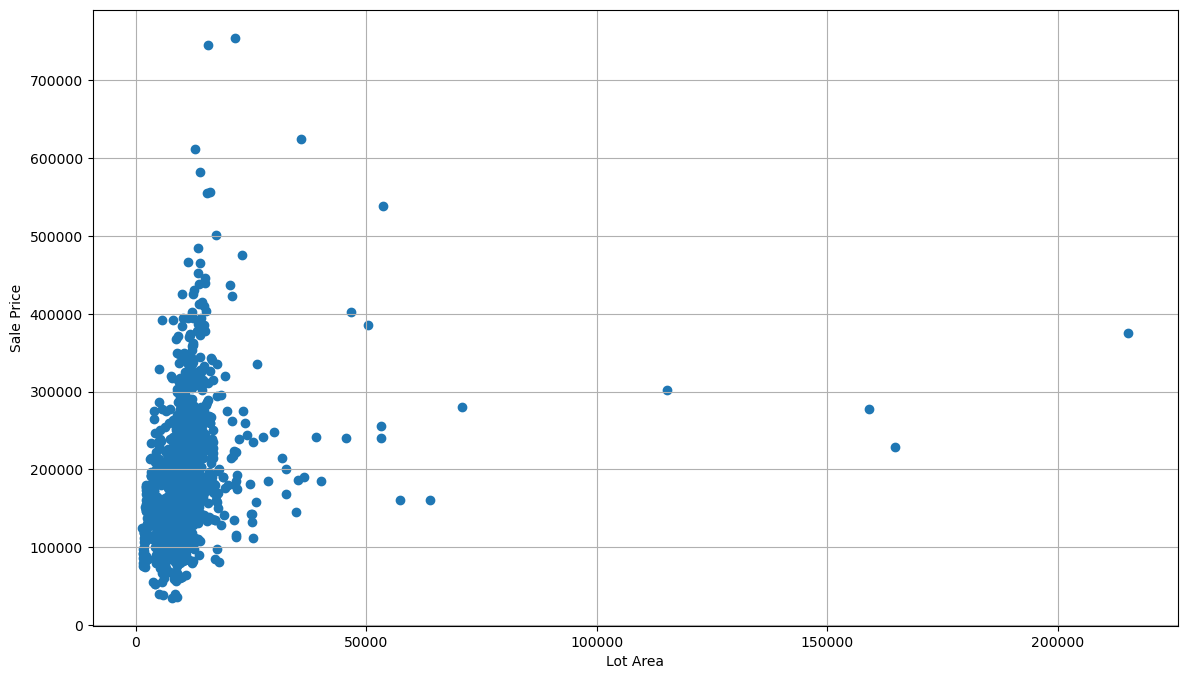

In [306]:
fig, ax = plt.subplots(figsize = (14, 8))
ax.grid()
ax.scatter(data_train['LotArea'], data_train['SalePrice'])
ax.set_xlabel('Lot Area')
ax.set_ylabel('Sale Price')
plt.show()

In [307]:
data_train = data_train[data_train['LotArea'] < 100000]

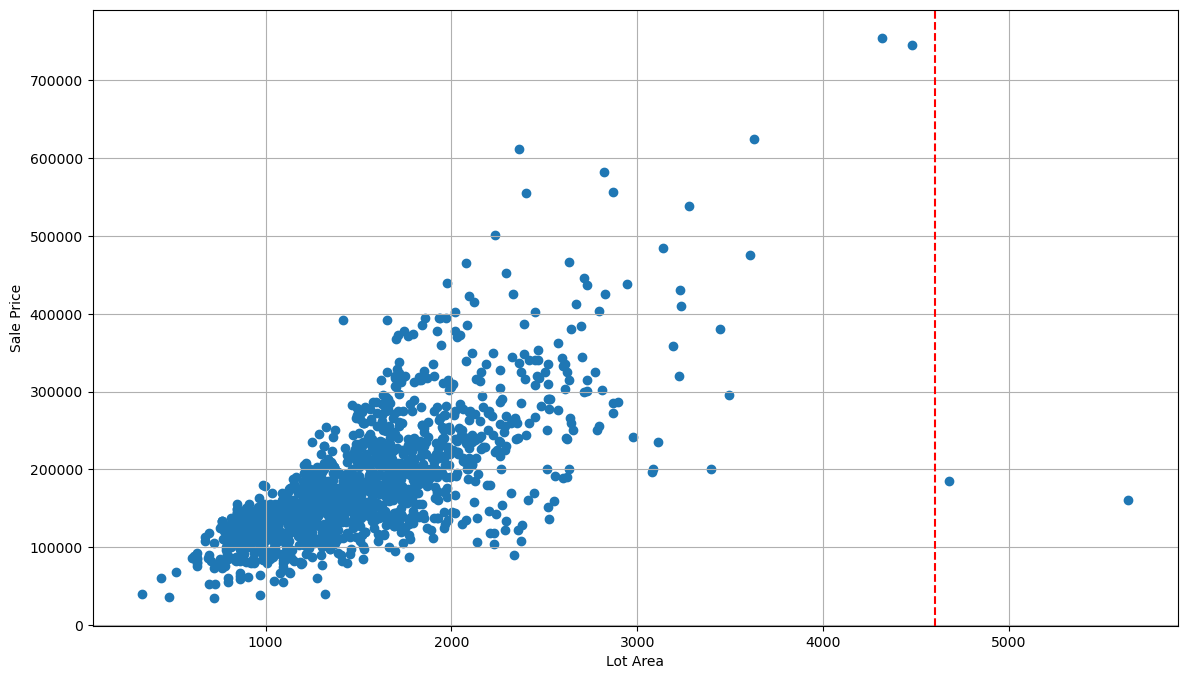

In [ ]:
fig, ax = plt.subplots(figsize = (14, 8))
ax.grid()
ax.scatter(data_train['GrLivArea'], data_train['SalePrice'])
ax.set_xlabel('Lot Area')
ax.set_ylabel('Sale Price')
ax.axvline(4600, c='r', ls='--')
plt.show()

In [309]:
data_train = data_train[data_train['GrLivArea'] < 4600]

In [310]:
data= pd.concat([data_train.drop('SalePrice', axis= 1), data_test])
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


## Missing Values Handling

The datasets contains large amount of missing values across most of the features. 

- Some features do not indicate missing information, but rather the absence of the feature (e.g "FireplaceQu"). These features were filled with None.
- For sevaral neighborhood-related features imputation were made with mode values across the common neighborhood.
- Others were filled with 0.

In [311]:
nans = data.isna().sum()
nans = nans[nans > 0]
nans

MSZoning           4
LotFrontage      483
Alley           2715
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType      1764
MasVnrArea        23
BsmtQual          81
BsmtCond          82
BsmtExposure      82
BsmtFinType1      79
BsmtFinSF1         1
BsmtFinType2      80
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
Electrical         1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu     1420
GarageType       157
GarageYrBlt      159
GarageFinish     159
GarageCars         1
GarageArea         1
GarageQual       159
GarageCond       159
PoolQC          2904
Fence           2342
MiscFeature     2810
SaleType           1
dtype: int64

In [312]:
features_nans_none = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType']
data[features_nans_none] = data[features_nans_none].fillna('None')

features_nans_mode = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'Electrical', 'KitchenQual', 'Functional', 'SaleType', 'LotFrontage']
data[features_nans_mode] = data.groupby('Neighborhood')[features_nans_mode].transform(lambda x : x.fillna(x.mode()[0]))

features_nans_zero = ['GarageYrBlt', 'MasVnrArea', 'BsmtHalfBath', 'BsmtFullBath', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageCars', 'GarageArea']
data[features_nans_zero] = data[features_nans_zero].fillna(0)


In [313]:
nans = data.isna().sum()
nans = nans[nans > 0]
nans

Series([], dtype: int64)

## Target variable distribution

The distribution of the target variable wre analyzed before model training. To deadl with right-skewness logarithmic transformation were done to improve model stability and overall performance.

C:\Users\vlads\AppData\Local\Temp\ipykernel_24388\1537659136.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, kde = False, fit=scipy.stats.norm)


<Axes: xlabel='SalePrice'>

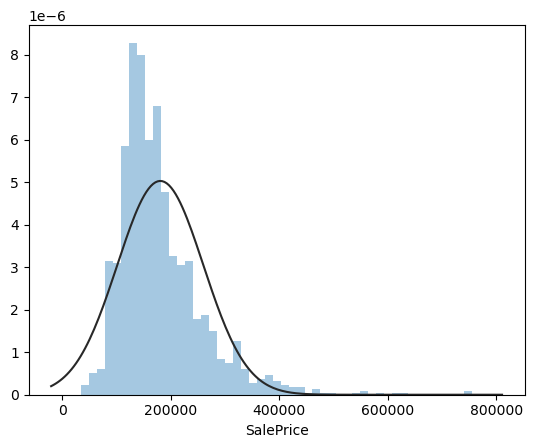

In [314]:
y = data_train['SalePrice']
sns.distplot(y, kde = False, fit=scipy.stats.norm)

C:\Users\vlads\AppData\Local\Temp\ipykernel_24388\3438376139.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, kde = False, fit=scipy.stats.lognorm)


<Axes: xlabel='SalePrice'>

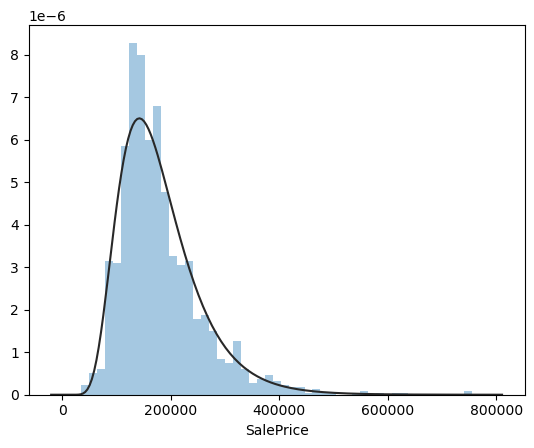

In [315]:
sns.distplot(y, kde = False, fit=scipy.stats.lognorm)

In [316]:
y = np.log(data_train['SalePrice'])

## Feature engineering

- Two aggregated features, such as "TotalArea" and "TotalPorch" were created.
- Some more Binary Indicator features were created to indicate presence or absence of some gouse components.
- Finally, all categorical features were one-hot-encoded

In [317]:
data['TotalArea'] = data['GrLivArea'] + data['TotalBsmtSF']
data['TotalPorch'] = data['OpenPorchSF'] + data['EnclosedPorch'] + data['3SsnPorch'] + data['ScreenPorch']
data['Pool'] = data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
data['2ndFloor'] = data['2ndFlrSF'].apply(lambda x: 1 if x > 0 else 0)
data['Garage'] = data['GarageCars'].apply(lambda x: 1 if x > 0 else 0)
data['Bsmt'] = data['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
data['Fireplace'] = data['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)
data['Porch'] = data['TotalPorch'].apply(lambda x: 1 if x > 0 else 0)
data = pd.get_dummies(data)

## Hyperparameters optimization

The data were split into training features(X_train) and test features(X_test)

Several machine learning algorithms were evaluated, such as XGBoost, LGBM, RandomForest, Lasso and Ridge regressions, and their hyperparameters were tuned with 'RandomizedSearchCV' using 5-fold cross-validation.

Root Mean Squared error was selected as evaluation metric as it is the main metric in the original task.

In [319]:
X_train = data.iloc[:len(data_train)]
X_test  = data.iloc[len(data_train):]

In [320]:
kF = KFold(n_splits = 5, shuffle=True, random_state=42)
rmse = lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred))
rmse_scorer = make_scorer(rmse, greater_is_better=False)

xgb_pg = {'n_estimators': [400, 600, 800, 1000],'max_depth': [3, 6, 9],'learning_rate': [0.01, 0.05, 0.1],'min_child_weight': [1, 5, 10]}
lgbm_pg = {'n_estimators': [400, 800, 1000],'max_depth': [-1, 3, 6, 9],'learning_rate': [0.01, 0.05, 0.1],'min_child_samples': [5, 20], 'num_leaves': [15, 31, 63, 127]}
ridge_pg = {"alpha": np.logspace(-1, 2, 500)} 
lasso_pg = {"alpha": np.logspace(-5, -1, 500)} 
rf_pg = {'n_estimators': [100, 300, 500, 800],'max_depth': [None,20, 30],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2']} 
cat_pg = {'iterations': [500, 800], 'depth': [2,7, 9],'learning_rate': [0.001,0.1, 0.01]}

In [321]:
search_xgb = RandomizedSearchCV(XGBRegressor(error_score='raise'), param_distributions=xgb_pg, cv=kF, n_iter=100, random_state=42, n_jobs=-1, scoring=rmse_scorer )
search_lgbm = RandomizedSearchCV(LGBMRegressor(), param_distributions=lgbm_pg, cv=kF, n_iter=100, random_state=42, n_jobs=-1, scoring=rmse_scorer )
search_rf = RandomizedSearchCV(RandomForestRegressor(), param_distributions=rf_pg, cv=kF, n_iter=100, random_state=42, n_jobs=-1, scoring=rmse_scorer)
search_ls = RandomizedSearchCV(Lasso(), param_distributions=lasso_pg, cv=kF, n_iter=100, random_state=42, n_jobs=-1, scoring=rmse_scorer )
search_rg = RandomizedSearchCV(Ridge(), param_distributions=ridge_pg, cv=kF, n_iter=100, random_state=42, n_jobs=-1, scoring=rmse_scorer )
search_cat = RandomizedSearchCV(CatBoostRegressor(), param_distributions=cat_pg, cv=kF, random_state=42, n_jobs=-1, scoring=rmse_scorer )

In [322]:
search_xgb.fit(X_train,y)
print(f'XGB best score is {search_xgb.best_score_} with parameters: {search_xgb.best_params_}')

c:\Users\vlads\anaconda3\envs\lfugd\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:01:29] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "error_score" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB best score is -0.1198730757666859 with parameters: {'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05}


In [323]:
search_lgbm.fit(X_train,y)
print(f'LGB best score is {search_lgbm.best_score_} with parameters: {search_lgbm.best_params_}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4239
[LightGBM] [Info] Number of data points in the train set: 1454, number of used features: 210
[LightGBM] [Info] Start training from score 12.022475
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [324]:
search_rf.fit(X_train,y)
print(f'RF best score is {search_rf.best_score_} with parameters: {search_rf.best_params_}')

RF best score is -0.13811020580227212 with parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [325]:
search_ls.fit(X_train,y)
print(f'Lasso best score is {search_ls.best_score_} with parameters: {search_ls.best_params_}')

Lasso best score is -0.10993439118580188 with parameters: {'alpha': np.float64(0.0004735334922917116)}


In [326]:
search_rg.fit(X_train,y)
print(f'Ridge best score is {search_rg.best_score_} with parameters: {search_rg.best_params_}')

Ridge best score is -0.11148219269875362 with parameters: {'alpha': np.float64(8.869431656014708)}


In [327]:
search_cat.fit(X_train,y)
print(f'CatBoost best score is {search_cat.best_score_} with parameters: {search_cat.best_params_}')

0:	learn: 0.3809167	total: 891us	remaining: 445ms
1:	learn: 0.3619838	total: 1.71ms	remaining: 426ms
2:	learn: 0.3442277	total: 2.26ms	remaining: 374ms
3:	learn: 0.3282561	total: 2.82ms	remaining: 350ms
4:	learn: 0.3137862	total: 3.44ms	remaining: 340ms
5:	learn: 0.2998652	total: 4.08ms	remaining: 336ms
6:	learn: 0.2890612	total: 4.7ms	remaining: 331ms
7:	learn: 0.2761445	total: 5.32ms	remaining: 327ms
8:	learn: 0.2668411	total: 5.97ms	remaining: 326ms
9:	learn: 0.2565169	total: 6.66ms	remaining: 326ms
10:	learn: 0.2485576	total: 7.34ms	remaining: 326ms
11:	learn: 0.2398619	total: 7.95ms	remaining: 323ms
12:	learn: 0.2333737	total: 8.53ms	remaining: 319ms
13:	learn: 0.2262745	total: 9.21ms	remaining: 320ms
14:	learn: 0.2212793	total: 9.78ms	remaining: 316ms
15:	learn: 0.2162714	total: 10.3ms	remaining: 312ms
16:	learn: 0.2113707	total: 10.8ms	remaining: 308ms
17:	learn: 0.2065861	total: 11.4ms	remaining: 306ms
18:	learn: 0.2025545	total: 12.1ms	remaining: 305ms
19:	learn: 0.1981695	tot

## Ensemble Learning and Submission Generation

To improve predicitve generalization ensemble learning were used with the best 4 models. 

Finally, prediction were generated in the form required for Kaggle Competition submission.

In [ ]:
models = [search.best_estimator_ for search in [search_xgb,search_rg, search_ls, search_cat, search_lgbm]]    # search_rf
predictions = [m.predict(X_test) for m in models]
predictions= np.average(predictions,axis=0)
predictions = pd.DataFrame({'Id': data_test['Id'], 'SalePrice': np.exp(predictions)})
predictions.to_csv('submission.csv', index=False)

## Final Results
The final model resulted in **0.1243** Root Mean Squared Error and placed **889 out of 4911 participants(18%)**